<h1><font color='blue'>Análise de Sentimentos e Sistemas de Recomendação</font></h1>
<h2><b>Prática U3-T1-V4.2-Avaliação da recomendação colaborativa</b></h2>


---

# Exemplo 01 - Avaliação de modelos baseados em *rating*

Métodos cujo foco é prever a nota estimada que um usuário 𝑢 daria para um item 𝑖.

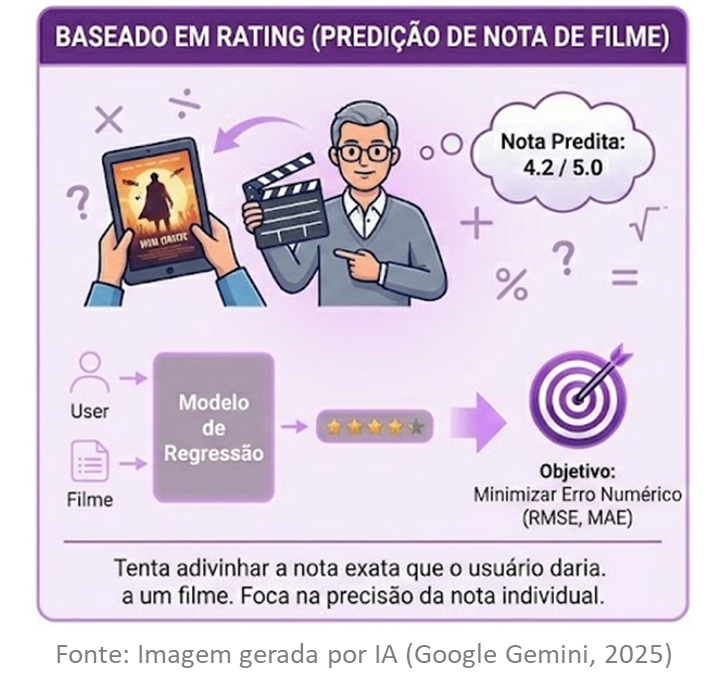

## Carregar os arquivos

### Carregar o arquivo de filmes

In [14]:
import pandas as pd
import numpy as np

In [15]:
movies = pd.read_csv('https://drive.google.com/uc?export=download&id=1yjGdaAJ5-YgIUx_1mLTcPqiZ8OI9TeqH', encoding='latin-1', low_memory=False)
movies['tags'] = movies['tags'].apply(lambda x: '' if isinstance(x,float) else x)
movies.set_index('movieId', inplace=True)
movies.head()

,title,genres,tags,tag_count,vote_count,vote_average,imdb_score
movieId,,,,,,,
1,Toy Story,Adventure|Animation|Children|Comedy|Fantasy,fun pixar,2,215,3.920930,3.894473
2,Jumanji,Adventure|Children|Fantasy,fantasy magic_board_game game robin_williams,4,110,3.431818,3.419009
3,Grumpier Old Men,Comedy|Romance,old moldy,2,52,3.259615,3.260033
4,Waiting to Exhale,Comedy|Drama|Romance,,0,7,2.357143,2.866377
5,Father of the Bride Part II,Comedy,pregnancy remake,2,49,3.071429,3.101070


### Carregar o arquivo de avaliações

In [16]:
ratings = pd.read_csv('https://drive.google.com/uc?export=download&id=1yCT7ximzeYFYHWAbJz3DO8_GL5raID74', encoding='latin-1', low_memory=False)
ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


## Biblioteca ***LibRecommender***

Biblioteca [LibRecommender](https://librecommender.readthedocs.io/en/latest/index.html) para sistemas de recomendação.



* Implementa diversos [algoritmos](https://github.com/massquantity/LibRecommender#references) populares de recomendação (mais detalhes [aqui](https://librecommender.readthedocs.io/en/latest/api/algorithms/))
* Pode trabalhar com sistemas de recomendação baseados em conteúdo ou colaborativos




In [17]:
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=UserWarning)

In [18]:
!pip install -q LibRecommender

In [19]:
from libreco.data import DatasetPure
from libreco.algorithms import SVD, SVDpp
from libreco.evaluation import evaluate
import tensorflow as tf


## Separar os conjuntos de treino (80%) e teste (20%) para avaliação

In [20]:
libdata = ratings[['userId', 'movieId', 'rating']].\
    rename(columns={"userId":"user", "movieId":"item", "rating": "label"})
libdata.head()

,user,item,label
0,1,1,4.0
1,1,3,4.0
2,1,6,4.0
3,1,47,5.0
4,1,50,5.0


In [21]:
# Lista de usuários únicos
unique_users = libdata['user'].unique()

# Criar amostra 80% dos usuários para treino
train_users = pd.Series(unique_users).sample(frac=0.8, random_state=42).values
train_df = libdata[libdata['user'].isin(train_users)]
test_df = libdata[~libdata['user'].isin(train_users)] # Usuarios que NÃO estão no treino

print(f"Total de usuários: {len(unique_users)}")
print(f"Usuários no treino: {train_df['user'].nunique()}")
print(f"Usuários no teste: {test_df['user'].nunique()}")

Total de usuários: 610
Usuários no treino: 488
Usuários no teste: 122


## Formatar arquivos para a LibRecommender

In [22]:
train_data, data_info = DatasetPure.build_trainset(train_df)
test_data = DatasetPure.build_testset(test_df)

## Treinar diversos modelos colaborativos de *rating*

In [23]:
from libreco.algorithms import SVD, ItemCF, SVDpp, UserCF, FM

results = []
models = []
metodos = [ ('SVD', 'SVD(task="rating",data_info=data_info)', False, ['rmse','mae']), \
            ('SVDpp', 'SVDpp(task="rating",data_info=data_info)', False, ['rmse','mae']), \
            ('UserCF', 'UserCF(task="rating",data_info=data_info)', False, ['rmse','mae']), \
            ('ItemCF', 'ItemCF(task="rating",data_info=data_info)', False, ['rmse','mae']),
            ('FM', 'FM(task="rating",data_info=data_info)', False, ['rmse','mae']),

          ]

for x in metodos:
    print(f'\n====> Model {x[0]}')
    tf.compat.v1.reset_default_graph()
    model = eval(x[1])
    model.fit(
        train_data,
        neg_sampling=x[2],
        verbose=0,
        metrics=x[3]
    )
    result = evaluate(
        model=model,
        data=test_data,
        neg_sampling=x[2],
        metrics=x[3]
    )
    print(result)
    models.append([ x[0], model])
    results.append([ 'LibRecommender', x[0], model, result ])



====> Model SVD
Training start time: 2026-02-18 14:42:16


eval_pointwise: 100%|██████████| 3/3 [00:00<00:00, 154.61it/s]


Detect 8192 unknown interaction(s), position: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48), np.int64(49), np.int64(50), np.int64(51), np.int64(52), np.int64(53), np.int64(54), np.int64(55), np.int64(56), np.int64(57), np.int64(58), np.int64(59), np.int64(60), np.int64(61), np.int64(62), np.int64(63), np.int64(64), np.int64(65), np.int64(66), np.int64(67), np.int64(68

eval_pointwise: 100%|██████████| 3/3 [00:00<00:00, 128.09it/s]


Detect 8192 unknown interaction(s), position: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48), np.int64(49), np.int64(50), np.int64(51), np.int64(52), np.int64(53), np.int64(54), np.int64(55), np.int64(56), np.int64(57), np.int64(58), np.int64(59), np.int64(60), np.int64(61), np.int64(62), np.int64(63), np.int64(64), np.int64(65), np.int64(66), np.int64(67), np.int64(68

...

Detect 8192 unknown interaction(s), position: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48), np.int64(49), np.int64(50), np.int64(51), np.int64(52), np.int64(53), np.int64(54), np.int64(55), np.int64(56), np.int64(57), np.int64(58), np.int64(59), np.int64(60), np.int64(61), np.int64(62), np.int64(63), np.int64(64), np.int64(65), np.int64(66), np.int64(67), np.int64(68

eval_pointwise: 100%|██████████| 3/3 [00:00<00:00, 52.89it/s]


Detect 8192 unknown interaction(s), position: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48), np.int64(49), np.int64(50), np.int64(51), np.int64(52), np.int64(53), np.int64(54), np.int64(55), np.int64(56), np.int64(57), np.int64(58), np.int64(59), np.int64(60), np.int64(61), np.int64(62), np.int64(63), np.int64(64), np.int64(65), np.int64(66), np.int64(67), np.int64(68

eval_pointwise: 100%|██████████| 3/3 [00:00<00:00, 75.37it/s]

Detect 8192 unknown interaction(s), position: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48), np.int64(49), np.int64(50), np.int64(51), np.int64(52), np.int64(53), np.int64(54), np.int64(55), np.int64(56), np.int64(57), np.int64(58), np.int64(59), np.int64(60), np.int64(61), np.int64(62), np.int64(63), np.int64(64), np.int64(65), np.int64(66), np.int64(67), np.int64(68

## Comparação entre todas as abordagens colaborativas

In [24]:
flattened_results = []

for row in results:
    data = {'Biblioteca': row[0],'Abordagem': row[1],'Modelo': row[2]}
    data.update(row[3])
    flattened_results.append(data)

df_results = pd.DataFrame(flattened_results)
df_results.drop('Modelo', axis=1)


,Biblioteca,Abordagem,rmse,mae
0,LibRecommender,SVD,0.985245,0.773258
1,LibRecommender,SVDpp,1.007344,0.790096
2,LibRecommender,UserCF,1.027918,0.815139
3,LibRecommender,ItemCF,1.027918,0.815139
4,LibRecommender,FM,0.952636,0.749764


# Exemplo 02 -Avaliação de modelos baseados em *ranking*

Existem outros tipos de métodos, cujo foco não é prever a nota exata, mas sim aprender uma ordem de preferência
𝑢 prefere o item 𝑖 ao item 𝑗. Estes métodos se adaptam melhor a cenários de e-commerce, streaming, música, etc.


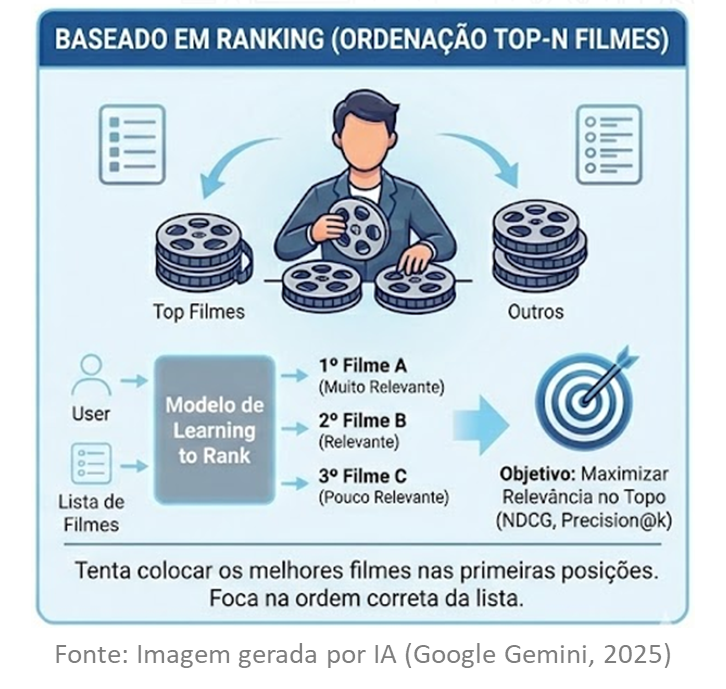

## Treinar diversos modelos baseados em *ranking*

In [25]:
from libreco.algorithms import FM, BPR, NCF

results = []
models = []
metodos = [ ('FM', 'FM(task="ranking",data_info=data_info,n_epochs=5,lr=1e-3)', True, ["precision", "recall", "ndcg"]),
            ('BPR', 'BPR(task="ranking",data_info=data_info,n_epochs=5,lr=1e-3)', True, ["precision", "recall", "ndcg"]),
            ('NCF', 'NCF(task="ranking",data_info=data_info,n_epochs=5,lr=1e-3)', True, ["precision", "recall", "ndcg"])
            ]

for x in metodos:
    print(f'\n====> Model {x[0]}')
    tf.compat.v1.reset_default_graph()
    model = eval(x[1])
    model.fit(
        train_data,
        neg_sampling=x[2],
        verbose=0,
        metrics=x[3]
    )
    result = evaluate(
        model=model,
        data=test_data,
        neg_sampling=x[2],
        metrics=x[3]
    )
    print(result)
    models.append([ x[0], model])
    results.append([ 'LibRecommender', x[0], model, result ])



====> Model FM
Training start time: 2026-02-18 14:46:56
total params: 163,116 | embedding params: 163,066 | network params: 50


eval_listwise: 100%|██████████| 1/1 [00:00<00:00, 4341.93it/s]


{'precision': np.float64(1.0), 'recall': np.float64(0.002170138888888889), 'ndcg': np.float64(1.0)}

====> Model BPR
Training start time: 2026-02-18 14:47:05


eval_listwise: 100%|██████████| 1/1 [00:00<00:00, 4324.02it/s]


{'precision': np.float64(1.0), 'recall': np.float64(0.002170138888888889), 'ndcg': np.float64(1.0)}

====> Model NCF
Training start time: 2026-02-18 14:47:08


eval_listwise: 100%|██████████| 1/1 [00:00<00:00, 4350.94it/s]

{'precision': np.float64(1.0), 'recall': np.float64(0.002170138888888889), 'ndcg': np.float64(1.0)}


## Comparação entre todas as abordagens colaborativas

In [26]:
flattened_results = []

for row in results:
    data = {'Biblioteca': row[0],'Abordagem': row[1],'Modelo': row[2]}
    data.update(row[3])
    flattened_results.append(data)

df_results = pd.DataFrame(flattened_results)
df_results.drop('Modelo', axis=1)


,Biblioteca,Abordagem,precision,recall,ndcg
0,LibRecommender,FM,1.0,0.00217,1.0
1,LibRecommender,BPR,1.0,0.00217,1.0
2,LibRecommender,NCF,1.0,0.00217,1.0
